In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

# Path to your Google Drive folder (Update this)
root_directory = "/content/drive/MyDrive/split_dataset"  # Change this if your images are in a different folder

total_folders = 0
total_images = 0

print("\n📂 Counting images in each folder...\n")

for foldername, subfolders, filenames in os.walk(root_directory):
    image_count = sum(1 for file in filenames if file.lower().endswith((".jpg", ".png", ".jpeg")))
    if image_count > 0:
        print(f"📁 {foldername} → {image_count} images")
        total_folders += 1
        total_images += image_count

print("\n----------------------------")
print(f"📂 Total Folders: {total_folders}")
print(f"🖼️ Total Images: {total_images}")
print("----------------------------")



📂 Counting images in each folder...

📁 /content/drive/MyDrive/split_dataset/train/sklm gate → 49 images
📁 /content/drive/MyDrive/split_dataset/train/sbi → 35 images
📁 /content/drive/MyDrive/split_dataset/train/sac → 82 images
📁 /content/drive/MyDrive/split_dataset/train/yoga shala → 74 images
📁 /content/drive/MyDrive/split_dataset/train/nuzvid gate → 80 images
📁 /content/drive/MyDrive/split_dataset/train/girls mess → 67 images
📁 /content/drive/MyDrive/split_dataset/train/food court → 37 images
📁 /content/drive/MyDrive/split_dataset/train/dh4 → 23 images
📁 /content/drive/MyDrive/split_dataset/train/dh1&2 → 23 images
📁 /content/drive/MyDrive/split_dataset/train/boys mess → 68 images
📁 /content/drive/MyDrive/split_dataset/train/dh3 → 25 images
📁 /content/drive/MyDrive/split_dataset/train/academic block 3(ab3) → 44 images
📁 /content/drive/MyDrive/split_dataset/train/academic block2(ab2) → 42 images
📁 /content/drive/MyDrive/split_dataset/train/academic block 1(ab1) → 50 images
📁 /content/d

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Paths
merged_path = "/content/drive/MyDrive/dataset"  # where all your class folders are
split_path = "/content/drive/MyDrive/split_dataset"    # where to save train/val/test splits

# Create split directories
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(split_path, split), exist_ok=True)

# Loop through each class folder
for class_name in os.listdir(merged_path):
    class_dir = os.path.join(merged_path, class_name)
    if not os.path.isdir(class_dir):
        continue

    # Get list of image files
    images = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # Split into train, val, test
    train_imgs, temp_imgs = train_test_split(images, test_size=0.3, random_state=42)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=1/3, random_state=42)  # 0.1 of total

    for split_name, split_imgs in zip(['train', 'val', 'test'], [train_imgs, val_imgs, test_imgs]):
        split_class_dir = os.path.join(split_path, split_name, class_name)
        os.makedirs(split_class_dir, exist_ok=True)

        for img in split_imgs:
            src = os.path.join(class_dir, img)
            dst = os.path.join(split_class_dir, img)
            shutil.copy2(src, dst)

print("✅ Dataset successfully split into train, val, and test!")


✅ Dataset successfully split into train, val, and test!


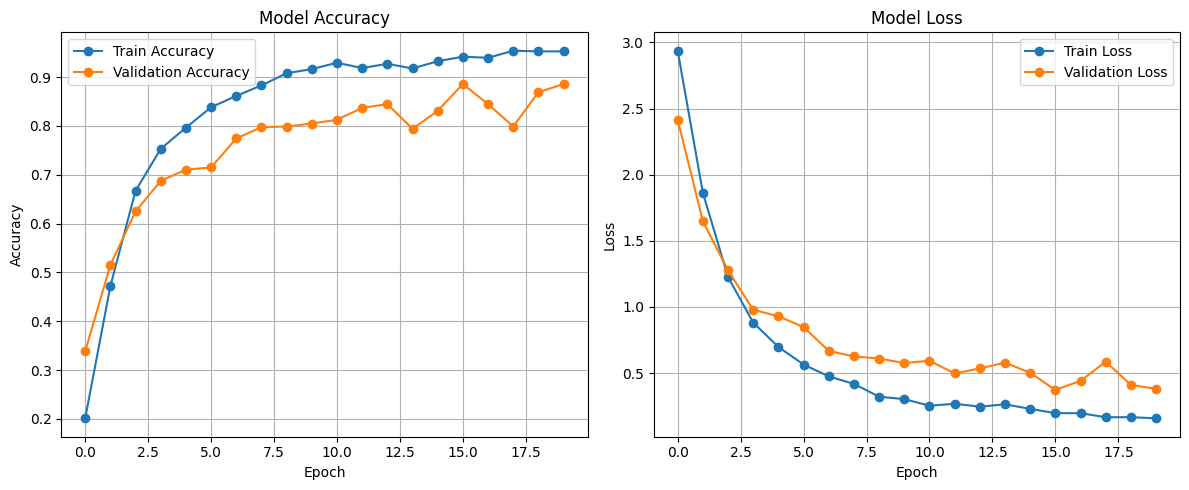

In [ ]:
import pickle
import matplotlib.pyplot as plt

#  Load training history
with open("/content/drive/MyDrive/history_mobilenetv2.pkl", "rb") as f:
    history = pickle.load(f)

#  Accuracy Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

#  Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Train Loss', marker='o')
plt.plot(history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,615,012 (9.98 MB)

 Trainable params: 357,026 (1.36 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 2 (12.00 B)

In [ ]:
import pandas as pd
import itertools

# Your 34 location labels
locations = [
    "central library", "k2 ground", "nuzvid clinic", "I1 boys hostel", "I2 boys hostel",
    "I3 adminstrative block", "academic block 1(ab1)", "academic block 3(ab3)", "academic block2(ab2)",
    "beta cluster", "boys mess", "chancellor office", "dh1&2", "dh3", "dh4", "eta cluster",
    "food court", "gama cluster", "girls mess", "k2 girls hostel", "k3 girls hostel", "k4 girls hostel",
    "kappa cluster", "lambda cluster", "mue cluster", "nuzvid gate", "omega cluster", "p1 faculty block",
    "p2 faculty block", "p3 faculty block", "sac", "sbi", "sklm gate", "yoga shala"
]

# Generate all ordered pairs of different locations
pairs = list(itertools.permutations(locations, 2))

# Create the dataframe
df = pd.DataFrame(pairs, columns=["Source", "Destination"])
df["Path"] = "To be filled"  # Placeholder path

# Save to CSV
csv_path = "/content/drive/MyDrive/routes.csv"
df.to_csv(csv_path, index=False)

print(f"CSV generated and saved to: {csv_path}")


CSV generated and saved to: /content/drive/MyDrive/routes.csv


In [ ]:
import os
import pickle
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, LSTM, Reshape
from tensorflow.keras.callbacks import EarlyStopping

# Dataset and config
dataset_path = "/content/drive/MyDrive/split_dataset"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

#  Data Generators
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(dataset_path, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(dataset_path, "val"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(dataset_path, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)



Found 2280 images belonging to 34 classes.
Found 656 images belonging to 34 classes.
Found 345 images belonging to 34 classes.


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving image63.jpg to image63.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


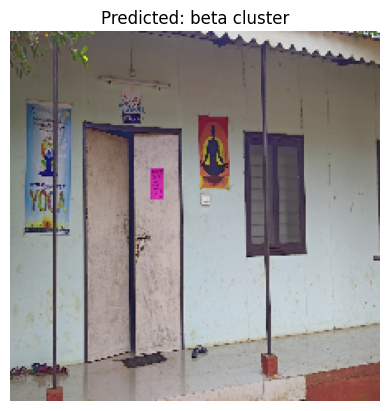

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = list(uploaded.keys())[0]
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)
class_labels = list(train_generator.class_indices.keys())
predicted_class = class_labels[np.argmax(prediction)]

# Show uploaded image
plt.imshow(img)
plt.axis("off")
plt.title(f"Predicted: {predicted_class}")
plt.show()


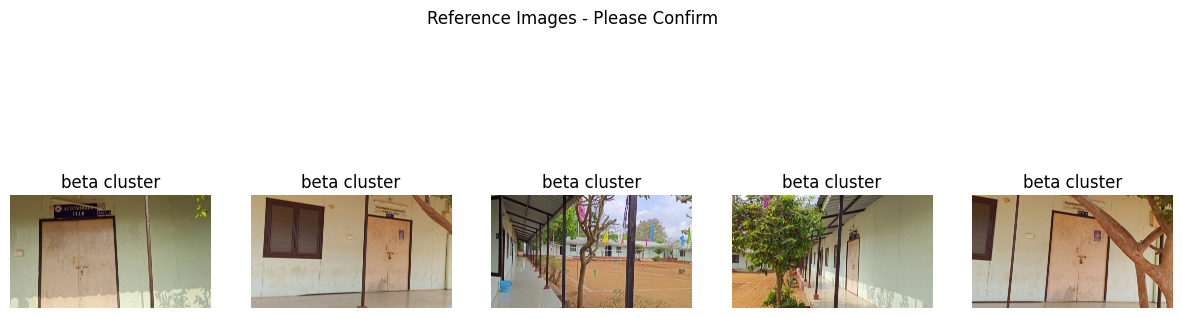

In [ ]:
import random
from PIL import Image

def show_reference_images(predicted_class, base_path, num_images=5):
    class_folder = os.path.join(base_path, predicted_class)
    if not os.path.exists(class_folder):
        print(f"[Error] Folder not found: {class_folder}")
        return

    all_images = os.listdir(class_folder)
    selected_images = random.sample(all_images, min(num_images, len(all_images)))

    plt.figure(figsize=(15, 5))
    for i, img_name in enumerate(selected_images):
        img_path = os.path.join(class_folder, img_name)
        img = Image.open(img_path)
        plt.subplot(1, num_images, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f'{predicted_class}')
    plt.suptitle("Reference Images - Please Confirm")
    plt.show()

# Call this with just the train folder path
show_reference_images(predicted_class, '/content/drive/MyDrive/split_dataset/train')


In [ ]:
from google.colab import files

print(" Upload source image (current location)")
uploaded_source = files.upload()

print(" Upload destination image")
uploaded_dest = files.upload()

 Upload source image (current location)


Saving beta_00004.jpg to beta_00004 (3).jpg
 Upload destination image


Saving dh3_00015.jpg to dh3_00015.jpg


In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.preprocessing import image
from google.colab import files


In [ ]:
import os
import pickle
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, GRU, Reshape
from tensorflow.keras.callbacks import EarlyStopping

# Dataset and config
dataset_path = "/content/drive/MyDrive/split_dataset"  # Path to your dataset
IMG_SIZE = (224, 224)  # Image size for MobileNetV2
BATCH_SIZE = 32  # Batch size for training

#  Data Generators
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1.0/255)

# Set up data generators for training, validation, and test
train_generator = train_datagen.flow_from_directory(
    os.path.join(dataset_path, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(dataset_path, "val"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(dataset_path, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

#  MobileNetV2 base
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze MobileNetV2 layers

#  Add GRU layer after feature extraction from MobileNetV2
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Pooling layer to reduce spatial dimensions
x = Reshape((1, -1))(x)  # Reshape to add time step dimension for GRU
x = GRU(64)(x)  # GRU layer for sequence modeling
x = Dense(128, activation='relu')(x)  # Fully connected layer
output = Dense(train_generator.num_classes, activation='softmax')(x)  # Output layer for classification

#  Compile model
model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# ⏱ Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

#  Train the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stopping]
)

#  Save model and training history
model.save("/content/drive/MyDrive/mobilenetv2_gru_model.h5")  # Save trained model
with open("/content/drive/MyDrive/history_mobilenetv2_gru.pkl", "wb") as f:
    pickle.dump(history.history, f)  # Save training history

print(" Training complete and model saved.")


Found 2280 images belonging to 34 classes.
Found 656 images belonging to 34 classes.
Found 345 images belonging to 34 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 1475s 20s/step - accuracy: 0.1430 - loss: 3.1409 - val_accuracy: 0.3765 - val_loss: 2.1611
Epoch 2/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 241s 3s/step - accuracy: 0.4789 - loss: 1.8212 - val_accuracy: 0.5610 - val_loss: 1.4972
Epoch 3/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 269s 4s/step - accuracy: 0.6744 - loss: 1.1839 - val_accuracy: 0.5808 - val_loss: 1.2115
Epoch 4/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 224s 3s/step - accuracy: 0.7582 - loss: 0.8435 - val_accuracy: 0.7149 - val_loss: 0.8876
Epoch 5/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 221s 3s/step - accuracy: 0.8240 - loss: 0.6450 - val_accuracy: 0.7210 - val_loss: 0.8561
Epoch 6/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 258s 4s/step - accuracy: 0.8518 - loss: 0.5301 - val_accuracy: 0.7652 - val_loss: 0.6880
Epoch 7/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 223s 3s/step - accuracy: 0.8608 - loss: 0.4642 - val_accuracy: 0.8049 - val_loss: 0.6476
Epoch 8/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 221s 3s/step - accuracy: 0.8948 - loss: 0.3775 - val_accuracy: 0.7698 -

 Training complete and model saved.


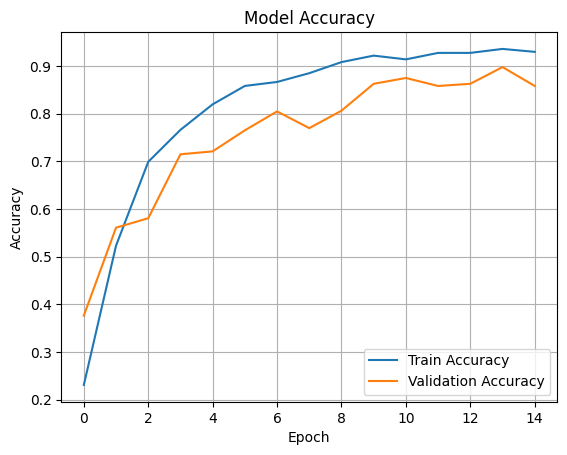

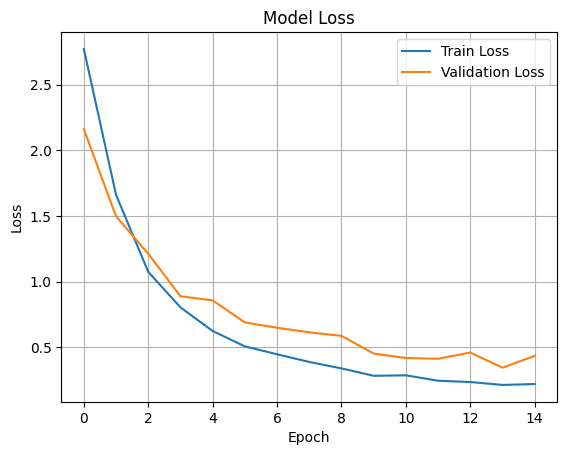

In [ ]:
import matplotlib.pyplot as plt
import pickle

# Load training history
with open("/content/drive/MyDrive/history_mobilenetv2_gru.pkl", "rb") as f:
    history = pickle.load(f)

# Plot accuracy
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot loss
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_generator)
print(f" Test Accuracy: {test_accuracy:.4f}")
print(f" Test Loss: {test_loss:.4f}")


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


11/11 ━━━━━━━━━━━━━━━━━━━━ 182s 17s/step - accuracy: 0.8838 - loss: 0.3646
 Test Accuracy: 0.8870
 Test Loss: 0.3444


In [ ]:
import os
import pickle
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, GRU, Reshape
from tensorflow.keras.callbacks import EarlyStopping

# Dataset and config
dataset_path = "/content/drive/MyDrive/split_dataset"  # Path to your dataset
IMG_SIZE = (224, 224)  # Image size for MobileNetV2
BATCH_SIZE = 32  # Batch size for training

#  Data Generators
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1.0/255)

# Set up data generators for training, validation, and test
train_generator = train_datagen.flow_from_directory(
    os.path.join(dataset_path, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(dataset_path, "val"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(dataset_path, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)




Found 2280 images belonging to 34 classes.
Found 656 images belonging to 34 classes.
Found 345 images belonging to 34 classes.


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/mobilenetv2_gru_model.h5")


In [ ]:
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,529,124 (9.65 MB)

 Trainable params: 271,138 (1.03 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 2 (12.00 B)

11/11 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step


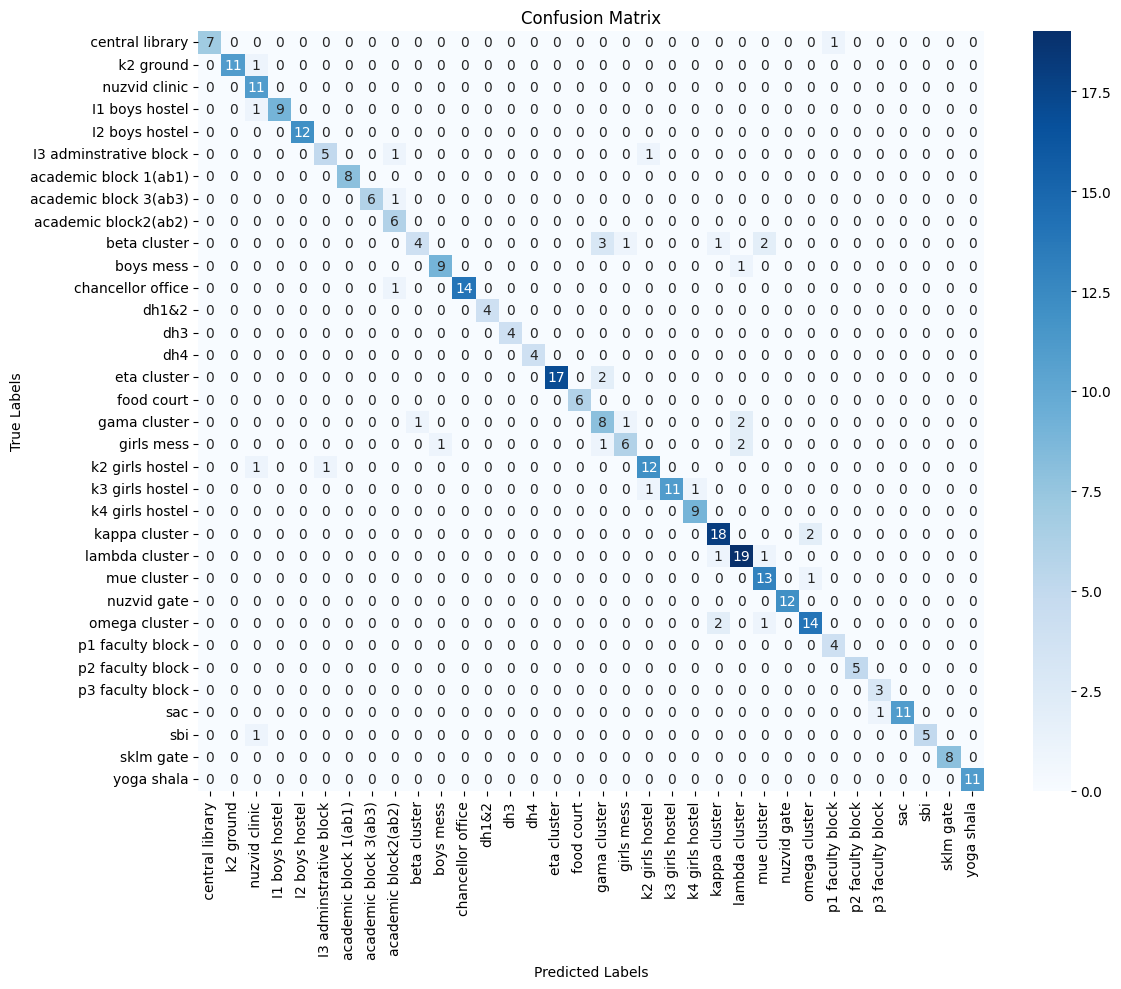

 Classification Report:

                        precision    recall  f1-score   support

       central library       1.00      0.88      0.93         8
             k2 ground       1.00      0.92      0.96        12
         nuzvid clinic       0.73      1.00      0.85        11
        I1 boys hostel       1.00      0.90      0.95        10
        I2 boys hostel       1.00      1.00      1.00        12
I3 adminstrative block       0.83      0.71      0.77         7
 academic block 1(ab1)       1.00      1.00      1.00         8
 academic block 3(ab3)       1.00      0.86      0.92         7
  academic block2(ab2)       0.67      1.00      0.80         6
          beta cluster       0.80      0.36      0.50        11
             boys mess       0.90      0.90      0.90        10
     chancellor office       1.00      0.93      0.97        15
                 dh1&2       1.00      1.00      1.00         4
                   dh3       1.00      1.00      1.00         4
              

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
# Get ground-truth labels
y_true = test_generator.classes

# Predict probabilities
y_pred_probs = model.predict(test_generator)

# Convert probabilities to predicted class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Get class labels
class_labels = list(test_generator.class_indices.keys())
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
# Classification report
report = classification_report(y_true, y_pred, target_names=class_labels)
print(" Classification Report:\n")
print(report)


In [2]:
import os
import pickle
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, LSTM, Reshape
from tensorflow.keras.callbacks import EarlyStopping

# Dataset and config
dataset_path = "/content/drive/MyDrive/split_dataset"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

#  Data Generators
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(dataset_path, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(dataset_path, "val"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(dataset_path, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)



Found 2280 images belonging to 34 classes.
Found 656 images belonging to 34 classes.
Found 345 images belonging to 34 classes.


In [3]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/mobilenetv2_gru_model.h5")


In [ ]:
from google.colab import files
uploaded = files.upload()
